Matplotlib is building the font cache; this may take a moment.
Could not save font_manager cache [Errno 122] Disk quota exceeded


Total pbcor files: 6


/tmp/ipykernel_2553628/4131642517.py:27: RuntimeWarning: All-NaN slice encountered
  moment8 = np.nanmax(data, axis=0)


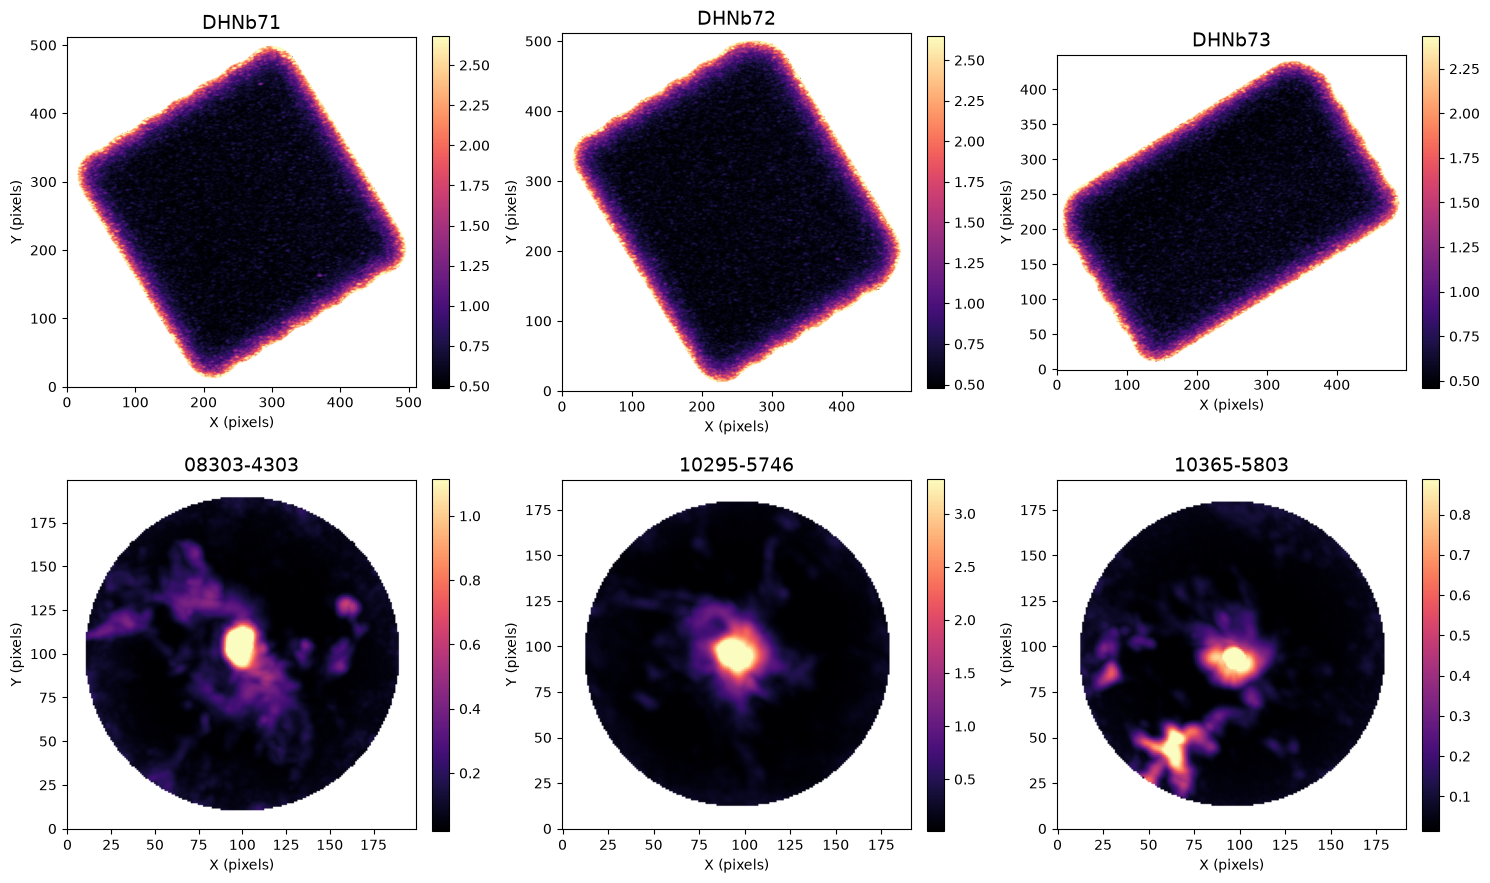

In [1]:
from pathlib import Path
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# Directory containing pbcor FITS files
final_dir = Path ("/users/skaur/lustre/Machine-Learning-Project/Astromorph_project/alma_TAP/final_fits_file")

# Find all pbcor FITS files
pbcor_files = sorted(final_dir.glob("*pbcor*.fits"))

print("Total pbcor files:", len(pbcor_files))

# Create 2x2 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, f in enumerate(pbcor_files[:6]):

    # Read FITS cube
    data = fits.getdata(f)

    # Remove singleton dimensions if present
    data = np.squeeze(data)

    # Create moment 8 map (maximum intensity)
    moment8 = np.nanmax(data, axis=0)

    # Plot moment 8 map
    im = axes[i].imshow(
        moment8,
        origin="lower",
        cmap="magma",
        vmin=np.nanpercentile(moment8, 5),
        vmax=np.nanpercentile(moment8, 99)
    )

    source_name = f.name.split("_")[5].split(".")[1]
    #print(source_name)
    axes[i].set_title(source_name, fontsize=14)
    axes[i].set_xlabel("X (pixels)")
    axes[i].set_ylabel("Y (pixels)")

    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

# Hide unused panels
for j in range(len(pbcor_files[:6]), 6):
    axes[j].axis("off")

plt.tight_layout()
plt.show()